## Final Project Submission

Please fill out:
* Student name: 
* Student pace: self paced / part time / full time
* Scheduled project review date/time: 
* Instructor name: 
* Blog post URL:


## Business Problem

### The company `KENVENTURES` has decided to create a new movie studio `KENHOOD`, with no background about creating movies. 
### Find out what types of films are currently doing the best at the box office. Translate those findings into actionable insights that the board of director's new movie studio `KENWOOD` can use to help decide what type of films to create.

## Business Objectives
- Which genres deliver the best financial return? (measured by ROI and median profit) 

- Which genres do best with an international audience 

- Which studios perform best and do they align with the top genres

## Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
# Load the compressed CSV
bom_df = pd.read_csv("zippedData/bom.movie_gross.csv.gz")
bom_df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [3]:
# Conect the SQLite database
conn = sqlite3.connect("zippedData/im.db")

# Inspect the tables available in the database
tables = pd.read_sql(
    '''
    SELECT name 
    FROM sqlite_master
    WHERE type= 'table' ;
''',
conn,)
print("Tables in im.db:")
display(tables)

Tables in im.db:


,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [4]:
# Load `movie_basics` and `movie_ratings` tables into pandas DataFrame
movies_basics = pd.read_sql(
    '''
    SELECT * 
    FROM movie_basics
''',
conn,
)
movies_basics.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [5]:
# Load `movie_basics` and `movie_ratings` tables into pandas DataFrame
movies_ratings = pd.read_sql(
    '''
    SELECT * 
    FROM movie_ratings
''',
conn,
)
movies_ratings.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


### Joining the three tables

In [6]:
# join DataFrame and tables before analysis
# Merging im.db tables on mivie_id
imdb_df = pd.merge(movies_basics, movies_ratings, on="movie_id", how="inner")

# Merging the combined imdbDataframe with bomdf on title
df = pd.merge(
    bom_df, imdb_df, left_on="title", right_on="primary_title", how="inner"
)

df.head()


,title,studio,domestic_gross,foreign_gross,year,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,Toy Story 3,BV,415000000.0,652000000,2010,tt0435761,Toy Story 3,Toy Story 3,2010,103.0,"Adventure,Animation,Comedy",8.3,682218
1,Inception,WB,292600000.0,535700000,2010,tt1375666,Inception,Inception,2010,148.0,"Action,Adventure,Sci-Fi",8.8,1841066
2,Shrek Forever After,P/DW,238700000.0,513900000,2010,tt0892791,Shrek Forever After,Shrek Forever After,2010,93.0,"Adventure,Animation,Comedy",6.3,167532
3,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000,2010,tt1325004,The Twilight Saga: Eclipse,The Twilight Saga: Eclipse,2010,124.0,"Adventure,Drama,Fantasy",5.0,211733
4,Iron Man 2,Par.,312400000.0,311500000,2010,tt1228705,Iron Man 2,Iron Man 2,2010,124.0,"Action,Adventure,Sci-Fi",7.0,657690


### Data Inspection

##### 1. Structural and Dimensional assessment

In [7]:
# Understanding the format and column entries to preview the data
df.head()


,title,studio,domestic_gross,foreign_gross,year,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,Toy Story 3,BV,415000000.0,652000000,2010,tt0435761,Toy Story 3,Toy Story 3,2010,103.0,"Adventure,Animation,Comedy",8.3,682218
1,Inception,WB,292600000.0,535700000,2010,tt1375666,Inception,Inception,2010,148.0,"Action,Adventure,Sci-Fi",8.8,1841066
2,Shrek Forever After,P/DW,238700000.0,513900000,2010,tt0892791,Shrek Forever After,Shrek Forever After,2010,93.0,"Adventure,Animation,Comedy",6.3,167532
3,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000,2010,tt1325004,The Twilight Saga: Eclipse,The Twilight Saga: Eclipse,2010,124.0,"Adventure,Drama,Fantasy",5.0,211733
4,Iron Man 2,Par.,312400000.0,311500000,2010,tt1228705,Iron Man 2,Iron Man 2,2010,124.0,"Action,Adventure,Sci-Fi",7.0,657690


In [8]:
df.tail()

,title,studio,domestic_gross,foreign_gross,year,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
3022,Souvenir,Strand,11400.0,NaN,2018,tt2387692,Souvenir,Souvenir,2016,90.0,"Drama,Music,Romance",6.0,823
3023,Souvenir,Strand,11400.0,NaN,2018,tt2389092,Souvenir,Souvenir,2014,86.0,"Comedy,Romance",5.9,9
3024,Beauty and the Dogs,Osci.,8900.0,NaN,2018,tt6776572,Beauty and the Dogs,Aala Kaf Ifrit,2017,100.0,"Crime,Drama,Thriller",7.0,1016
3025,The Quake,Magn.,6200.0,NaN,2018,tt6523720,The Quake,Skjelvet,2018,106.0,"Action,Drama,Thriller",6.2,5270
3026,An Actor Prepares,Grav.,1700.0,NaN,2018,tt5718046,An Actor Prepares,An Actor Prepares,2018,97.0,Comedy,5.0,388


In [9]:
# Checking the dimension of the data by determining the overall row and column counts
print(f"The DataFrame has {df.shape[0]} Rows, and {df.shape[1]} Columns")

The DataFrame has 3027 Rows, and 13 Columns


In [10]:
# Ispecting Metadata and Data Types by verifying column names, non-null counts and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3027 entries, 0 to 3026
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            3027 non-null   object 
 1   studio           3024 non-null   object 
 2   domestic_gross   3005 non-null   float64
 3   foreign_gross    1832 non-null   object 
 4   year             3027 non-null   int64  
 5   movie_id         3027 non-null   object 
 6   primary_title    3027 non-null   object 
 7   original_title   3027 non-null   object 
 8   start_year       3027 non-null   int64  
 9   runtime_minutes  2980 non-null   float64
 10  genres           3020 non-null   object 
 11  averagerating    3027 non-null   float64
 12  numvotes         3027 non-null   int64  
dtypes: float64(3), int64(3), object(7)
memory usage: 307.6+ KB


##### Data Types issues
- `foreign_gross` is stored as string instead of float
- `year` is stored as integer instead of datetime

##### 2. Statistical Profiling

In [11]:
# Numerical Summaeries 
df.describe()

,domestic_gross,year,start_year,runtime_minutes,averagerating,numvotes
count,3.005000e+03,3027.000000,3027.000000,2980.000000,3027.000000,3.027000e+03
mean,3.064033e+07,2014.077635,2013.783284,107.217114,6.457582,6.170030e+04
std,6.671629e+07,2.442245,2.466955,20.073886,1.012277,1.255132e+05
min,1.000000e+02,2010.000000,2010.000000,3.000000,1.600000,5.000000e+00
25%,1.390000e+05,2012.000000,2012.000000,94.000000,5.900000,2.117000e+03
50%,2.000000e+06,2014.000000,2014.000000,105.000000,6.600000,1.310900e+04
75%,3.250000e+07,2016.000000,2016.000000,118.000000,7.100000,6.276550e+04
max,7.001000e+08,2018.000000,2019.000000,272.000000,9.200000,1.841066e+06


In [12]:
# Categorical Summaries
df.describe(include=['O'])
df['studio'].value_counts().head()
df['genres'].value_counts().head()

genres
Drama                   317
Comedy,Drama            133
Comedy,Drama,Romance    132
Drama,Romance           112
Documentary             110
Name: count, dtype: int64

##### 3. Data Quality Verification

In [13]:
# Checking for missing values
missing = df.isna().sum()

# Percentage of missing values
pct_missing = (missing/len(df))*100

pd.DataFrame({'Missing Count': missing, 'Percentage (%)': pct_missing})


,Missing Count,Percentage (%)
title,0,0.000000
studio,3,0.099108
domestic_gross,22,0.726792
foreign_gross,1195,39.478031
year,0,0.000000
movie_id,0,0.000000
primary_title,0,0.000000
original_title,0,0.000000
start_year,0,0.000000
runtime_minutes,47,1.552692


In [14]:
# Checking for Duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


### Data Cleaning

##### 1. Standardizing Data Types

In [15]:
# Cleaning and convert <foreign_gross> to float
# Removing commas and white spaces and converting strig to interger
df['foreign_gross'] = df['foreign_gross'].astype(str).str.replace(',', '', regex=False)
df['foreign_gross'] = pd.to_numeric(df['foreign_gross'], errors='coerce')

# Converting `year` to datetime
# Converting the 4-digit integer into a datetime object
# df['year'] = pd.to_datetime(df['year'].astype(str), format='%Y')
# df['start_year'] = pd.to_datetime(df['start_year'].astype(str), format='%Y')
col = ["year", "start_year"]

for col in ["year", "start_year"]:
    df[col] = pd.to_datetime(df[col], errors="coerce").dt.year

# Verifying the updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3027 entries, 0 to 3026
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            3027 non-null   object 
 1   studio           3024 non-null   object 
 2   domestic_gross   3005 non-null   float64
 3   foreign_gross    1832 non-null   float64
 4   year             3027 non-null   int32  
 5   movie_id         3027 non-null   object 
 6   primary_title    3027 non-null   object 
 7   original_title   3027 non-null   object 
 8   start_year       3027 non-null   int32  
 9   runtime_minutes  2980 non-null   float64
 10  genres           3020 non-null   object 
 11  averagerating    3027 non-null   float64
 12  numvotes         3027 non-null   int64  
dtypes: float64(4), int32(2), int64(1), object(6)
memory usage: 283.9+ KB


In [26]:
df.head()

,title,studio,domestic_gross,foreign_gross,year,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes,genre_list,total_gross
0,Toy Story 3,BV,415000000.0,652000000.0,1970,tt0435761,Toy Story 3,Toy Story 3,1970,103.0,"Adventure,Animation,Comedy",8.3,682218,"[Adventure, Animation, Comedy]",1.067000e+09
1,Inception,WB,292600000.0,535700000.0,1970,tt1375666,Inception,Inception,1970,148.0,"Action,Adventure,Sci-Fi",8.8,1841066,"[Action, Adventure, Sci-Fi]",8.283000e+08
2,Shrek Forever After,P/DW,238700000.0,513900000.0,1970,tt0892791,Shrek Forever After,Shrek Forever After,1970,93.0,"Adventure,Animation,Comedy",6.3,167532,"[Adventure, Animation, Comedy]",7.526000e+08
3,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000.0,1970,tt1325004,The Twilight Saga: Eclipse,The Twilight Saga: Eclipse,1970,124.0,"Adventure,Drama,Fantasy",5.0,211733,"[Adventure, Drama, Fantasy]",6.985000e+08
4,Iron Man 2,Par.,312400000.0,311500000.0,1970,tt1228705,Iron Man 2,Iron Man 2,1970,124.0,"Action,Adventure,Sci-Fi",7.0,657690,"[Action, Adventure, Sci-Fi]",6.239000e+08


2. Inspecting Missing Values

In [16]:
# calculating missing values and their percentage in df
missing_count = df.isna().sum()
missing_percentage = (df.isna().mean() * 100).round(2)

# combining into a summary DataFrame
missing_df = pd.DataFrame (
    {
        'Missing Count' : missing_count,
        'Percentage (%)' : missing_percentage
    }
).sort_values(by='Missing Count', ascending=False)

# Show only columns with missing values
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Percentage (%)
foreign_gross,1195,39.48
runtime_minutes,47,1.55
domestic_gross,22,0.73
genres,7,0.23
studio,3,0.10


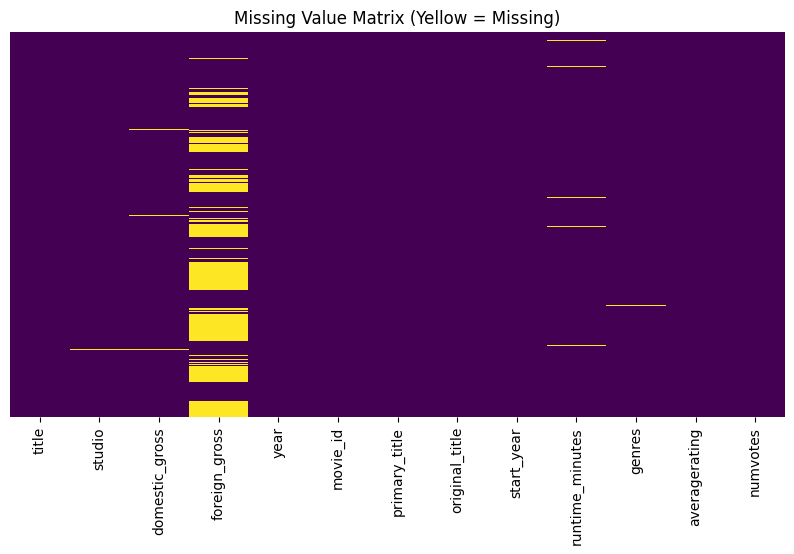

In [17]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Matrix (Yellow = Missing)')
plt.show()

3. Handling Missing Values

In [18]:
# Imputing foregn_gross with 0.0 (assuming domestic-only release)
df['foreign_gross'] = df['foreign_gross'].fillna(0.0)

# Impute runtime_minutes with overal mean runtime
df['runtime_minutes'] = df['runtime_minutes'].fillna(df['runtime_minutes'].mean())

# Impute categorical variables with unknown
df['studio'] = df['studio'].fillna('Unknown')
df['genres'] = df['genres'].fillna('Unknown')

# Impute domestic_gross using studion mean, falling back to overall mean
studio_mean = df.groupby('studio')['domestic_gross'].transform('mean')
df['domestic_gross'] = df['domestic_gross'].fillna(studio_mean).fillna(df['domestic_gross'].mean())

# Verify zero remaining missing values across the DataFrame
print("Remaining missing values per column:")
print(df.isna().sum)

Remaining missing values per column:
<bound method DataFrame.sum of       title  studio  domestic_gross  foreign_gross   year  movie_id  \
0     False   False           False          False  False     False   
1     False   False           False          False  False     False   
2     False   False           False          False  False     False   
3     False   False           False          False  False     False   
4     False   False           False          False  False     False   
...     ...     ...             ...            ...    ...       ...   
3022  False   False           False          False  False     False   
3023  False   False           False          False  False     False   
3024  False   False           False          False  False     False   
3025  False   False           False          False  False     False   
3026  False   False           False          False  False     False   

      primary_title  original_title  start_year  runtime_minutes  genres  \
0  

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3027 entries, 0 to 3026
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            3027 non-null   object 
 1   studio           3027 non-null   object 
 2   domestic_gross   3027 non-null   float64
 3   foreign_gross    3027 non-null   float64
 4   year             3027 non-null   int32  
 5   movie_id         3027 non-null   object 
 6   primary_title    3027 non-null   object 
 7   original_title   3027 non-null   object 
 8   start_year       3027 non-null   int32  
 9   runtime_minutes  3027 non-null   float64
 10  genres           3027 non-null   object 
 11  averagerating    3027 non-null   float64
 12  numvotes         3027 non-null   int64  
dtypes: float64(4), int32(2), int64(1), object(6)
memory usage: 283.9+ KB


In [20]:
df.describe()

,domestic_gross,foreign_gross,year,start_year,runtime_minutes,averagerating,numvotes
count,3.027000e+03,3.027000e+03,3027.0,3027.0,3027.000000,3027.000000,3.027000e+03
mean,3.049323e+07,4.736430e+07,1970.0,1970.0,107.217114,6.457582,6.170030e+04
std,6.651516e+07,1.144031e+08,0.0,0.0,19.917382,1.012277,1.255132e+05
min,1.000000e+02,0.000000e+00,1970.0,1970.0,3.000000,1.600000,5.000000e+00
25%,1.375000e+05,0.000000e+00,1970.0,1970.0,94.000000,5.900000,2.117000e+03
50%,2.000000e+06,2.400000e+06,1970.0,1970.0,105.000000,6.600000,1.310900e+04
75%,3.230000e+07,3.450000e+07,1970.0,1970.0,118.000000,7.100000,6.276550e+04
max,7.001000e+08,9.464000e+08,1970.0,1970.0,272.000000,9.200000,1.841066e+06


4. Feature Engineering

In [21]:
# Split comma-separated genre string into lists and explode to individual rows
df['genre_list'] = df['genres'].str.split(',')
df_exploded = df.explode('genre_list')

In [22]:
# combine revenue streams / combine earning metrics
df['foreign_gross'] = pd.to_numeric(df['foreign_gross'], errors='coerce')
df['domestic_gross'] = pd.to_numeric(df['domestic_gross'], errors='coerce')
df['total_gross'] = df['domestic_gross'] + df['foreign_gross']

### Data Analysis 

#### Answering **Which Studio Performs the Best and Do They Align With the Top Genres?**

In [23]:
# Evaluating top 10 genres by average foreign gross
genre_summary = (
    df_exploded.groupby('genre_list')['foreign_gross']
    .agg(['mean', 'median', 'count'])
    .sort_values(by='mean', ascending=False)
)

In [24]:
genre_summary

,mean,median,count
genre_list,,,
Adventure,1.771962e+08,92200000.0,439
Sci-Fi,1.753563e+08,74600000.0,135
Animation,1.672942e+08,78650000.0,152
Fantasy,1.084944e+08,18500000.0,170
Action,1.057623e+08,26700000.0,646
Family,7.082473e+07,15800000.0,117
Unknown,6.778157e+07,44700000.0,7
Comedy,4.923845e+07,4550000.0,926
Thriller,4.771815e+07,6000000.0,453


In [31]:
# top Studio Aggregation 
studio_perf  = (
    df.groupby("studio")
    .agg(
        total_revenue = ("total_gross", "sum"),
        mean_revenue=("total_gross", "mean"),
        movie_count=("title", "count")
    )
    .sort_values(by="total_revenue", ascending=False)
    .head(10).reset_index()
)
studio_perf

,studio,total_revenue,mean_revenue,movie_count
0,BV,4.256875e+10,4.388531e+08,97
1,Uni.,3.182447e+10,2.040030e+08,156
2,Fox,3.047577e+10,2.208389e+08,138
3,WB,2.609310e+10,2.192698e+08,119
4,Sony,1.829762e+10,2.055913e+08,89
5,Par.,1.807858e+10,2.008731e+08,90
6,WB (NL),1.107060e+10,2.050111e+08,54
7,LGF,8.369624e+09,9.197389e+07,91
8,P/DW,5.076500e+09,5.076500e+08,10
9,Wein.,4.089601e+09,5.048890e+07,81


In [32]:
# Exploring Multi-Genre Rows to map Studio Alignment
df_exploded = df.copy()
df_exploded["genres"] = df_exploded["genres"].astype(str).str.split(",")
df_exploded = df_exploded.explode("genres")

top_studios = studio_perf["studio"].tolist()
top_genres = (
    df_exploded.groupby("genres")["total_gross"].sum().nlargest(6).index.tolist()
)
alignment_df = df_exploded[
    (df_exploded["studio"].isin(top_studios))
    & (df_exploded["genres"].isin(top_genres))
]
pivot_alignment = alignment_df.pivot_table(
    index="studio", columns="genres", values="total_gross", aggfunc="sum"
).loc[top_studios]
df_exploded.head()

,title,studio,domestic_gross,foreign_gross,year,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes,genre_list,total_gross
0,Toy Story 3,BV,415000000.0,652000000.0,1970,tt0435761,Toy Story 3,Toy Story 3,1970,103.0,Adventure,8.3,682218,"[Adventure, Animation, Comedy]",1.067000e+09
0,Toy Story 3,BV,415000000.0,652000000.0,1970,tt0435761,Toy Story 3,Toy Story 3,1970,103.0,Animation,8.3,682218,"[Adventure, Animation, Comedy]",1.067000e+09
0,Toy Story 3,BV,415000000.0,652000000.0,1970,tt0435761,Toy Story 3,Toy Story 3,1970,103.0,Comedy,8.3,682218,"[Adventure, Animation, Comedy]",1.067000e+09
1,Inception,WB,292600000.0,535700000.0,1970,tt1375666,Inception,Inception,1970,148.0,Action,8.8,1841066,"[Action, Adventure, Sci-Fi]",8.283000e+08
1,Inception,WB,292600000.0,535700000.0,1970,tt1375666,Inception,Inception,1970,148.0,Adventure,8.8,1841066,"[Action, Adventure, Sci-Fi]",8.283000e+08


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_243876\3156535664.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


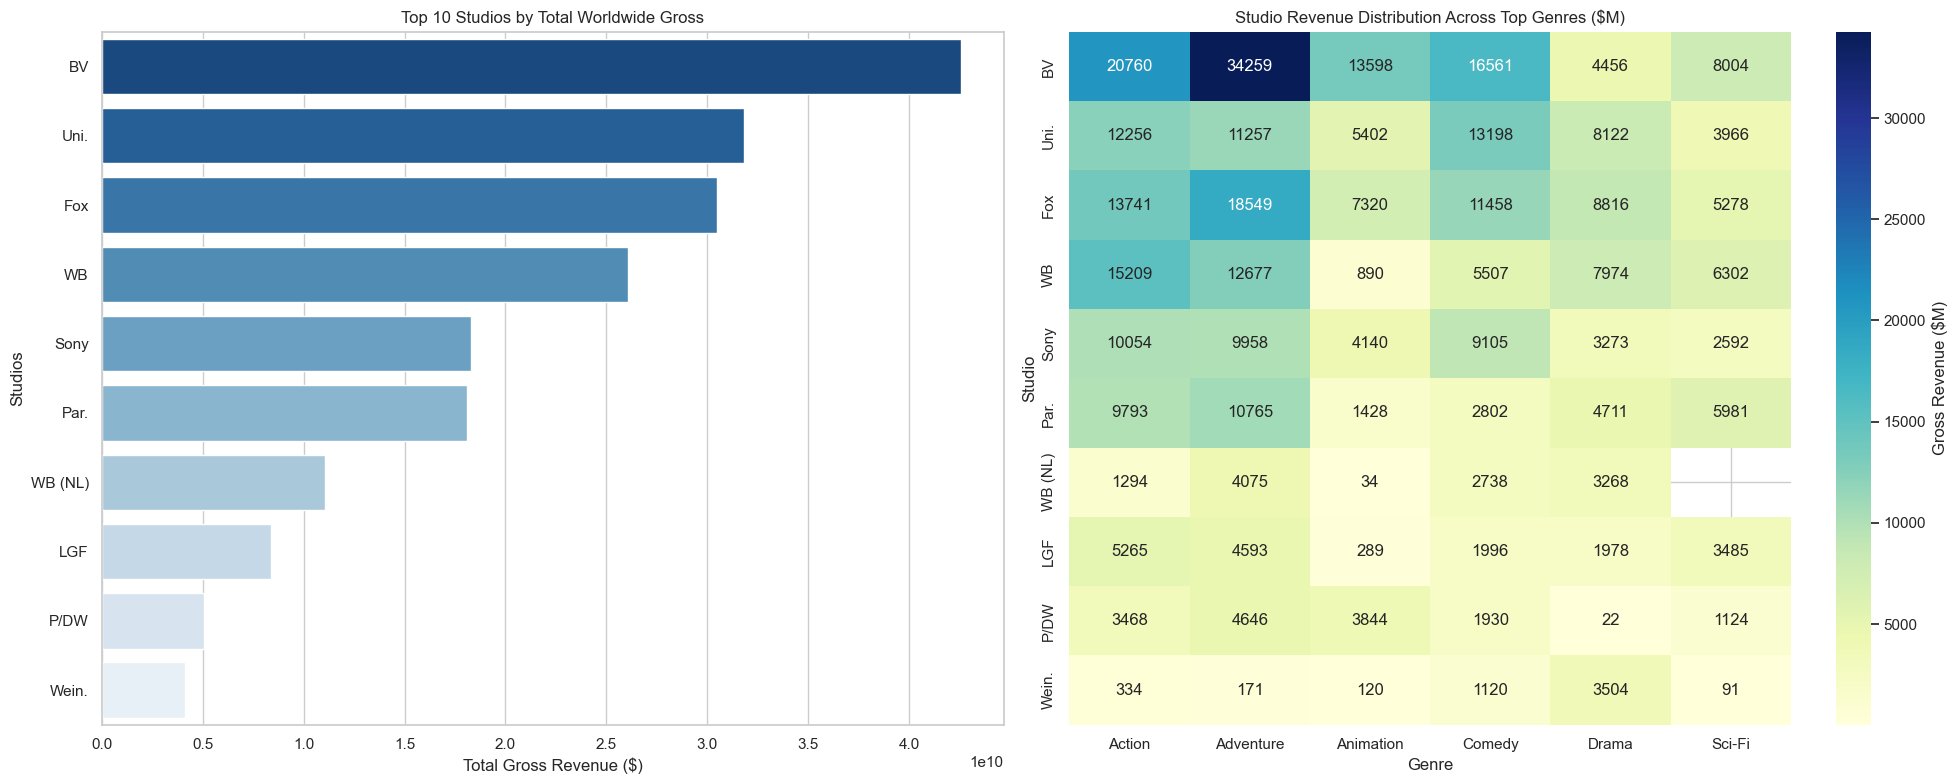

In [38]:
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))


sns.barplot(
    data = studio_perf,
    x= "total_revenue",
    y="studio",
    palette="Blues_r",
    ax=ax1
)
ax1.set(
    title="Top 10 Studios by Total Worldwide Gross",
    xlabel="Total Gross Revenue ($)",
    ylabel="Studios",
)

sns.heatmap(
    pivot_alignment / 1e6,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Gross Revenue ($M)"},
    ax=ax2,
)
ax2.set(
    title="Studio Revenue Distribution Across Top Genres ($M)",
    xlabel="Genre",
    ylabel="Studio",
)
plt.tight_layout()
plt.show()

#### **Insights Derived**
- **BV dominates all genres:** BV achieves market control through unmatched performance in **Adventure**($34.2B) and **Action**($20.7B), while maintaining a near monopoly on **Animation**($13.5B) and leading **Comedy**($16.5B).
- **Action and Adventure as Core Pillars:** Adventure generates the highest single-genre returns for market leader (BV at $34.2B, Fox at $18.5B, WB at $12.6B). Action acts as the safest volume play, reliably generating over $10B each fpr BV, WB, Fox, Universal, and Sony.
- **Strategic Animation Gaps:** While BV, Fox ($7.3B), and Universal ($5.4B) heavily capitalize on Animation, **WB** largely skips animated films ($890M), reallocating capital into Action ($15.2B) and Sci-Fi($6.3B).
- **Target Niche Models:**
    - **P/DW:** Highly specialized; nearly all revenue stems from **Adventure** ($4.6B) and **Animation** ($3.8B), with practically zero investment in Drama($22M).
    - **Weinstein Co.:** Operates a low-budget shop strategy, relying almost exclusively on **Drama** ($3.5B) while ignoring high-capital genres like Sci-Fi ($91M) and Action ($334M)
- **Universal and Fox Balanced Volume:** Both studios maintain stable revenue across four core pillars (Action, Adventure, Comedy, and Drama/Sci-Fi), buffering them against single-genre market downturns.

### **Business Recomendations**
- **Prioritize High-Yield Anchor Genres** by focusing 50%-60% of total capital expenditure on **Action & Adventure** titles. These genres consistently deliver the highest gross revenue floor across all top-tier studios.
- **Develop an Animation IP Pipeline** by investing in dedicated animation division or aquire specialized studios for the same portfolio. Animation yields massive long-tail returns and international theatrical legs, creating a scalable franchise ecosystem that is currently under-utilized.
- **Migrate Slate Risk with Low-Cap Drama** by incorporating a dual-tier release strategy. Use moderate-budget Drama and Thriller projects to build reliable, high-margin cash flow with lower financial exposure.
- **Scale via Sci-Fi & Action Hybrid Formulae** through combination of Sci-Fi with Action/Adventure rather than producing standalone, high-concept Sci-Fi.
- **Form Distribution Partnerships with Volume Leaders** like Uni. or WB. Accessing their global theatrical distribution networks captures foreign gross that account for over half of total worldwide revenue.